# HealthSpark-Claims-Analytics , Distributed Healthcare Claims Analytics & ML Pipeline

**End-to-end pipeline**: Synthetic Data -> PySpark ETL -> Feature Engineering -> **3-Model Comparison** (LR / Random Forest / GPU XGBoost) -> SHAP Interpretability -> Threshold Analysis

This notebook clones the **HealthSpark-Claims-Analytics** repository and runs the full pipeline using the project's source modules + GPU-accelerated XGBoost for fast iteration.

### What this notebook demonstrates
- **Distributed ETL with PySpark** , 500K claims, window functions, broadcast joins, Spark SQL
- **Class imbalance handling** , class weights (positive class is ~15% of data)
- **3-model comparison** , Logistic Regression baseline, tuned Random Forest, GPU XGBoost
- **SHAP values** , global + local clinical interpretability
- **Precision-Recall curve + threshold tuning** , operating-point selection for clinical deployment
- **Production artifacts** , serialized PipelineModel, FastAPI inference server

## Step 0 , Clone Repository & Install Dependencies

In [1]:
import os

# Clone the HealthSpark-Claims-Analytics repository
REPO_URL = 'https://github.com/Deepak-Lingala/HealthSpark-Claims-Analytics.git'
PROJECT_DIR = '/content/HealthSpark-Claims-Analytics'

# Always reset to /content first to avoid stale directory errors
os.chdir('/content')

if os.path.exists(PROJECT_DIR):
    !rm -rf {PROJECT_DIR}

!git clone {REPO_URL} {PROJECT_DIR}
os.chdir(PROJECT_DIR)
print(f'Working directory: {os.getcwd()}')
!ls -la

Cloning into '/content/HealthSpark-Claims-Analytics'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 75 (delta 33), reused 59 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 73.59 KiB | 2.63 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Working directory: /content/HealthSpark-Claims-Analytics
total 108
drwxr-xr-x 7 root root  4096 Apr 13 03:30 .
drwxr-xr-x 1 root root  4096 Apr 13 03:30 ..
-rw-r--r-- 1 root root  1820 Apr 13 03:30 docker-compose.yml
-rw-r--r-- 1 root root   299 Apr 13 03:30 Dockerfile
drwxr-xr-x 8 root root  4096 Apr 13 03:30 .git
drwxr-xr-x 3 root root  4096 Apr 13 03:30 .github
-rw-r--r-- 1 root root   327 Apr 13 03:30 .gitignore
-rw-r--r-- 1 root root 37546 Apr 13 03:30 healthspark_colab.ipynb
-rw-r--r-- 1 root root   737 Apr 13 03:30 Makefile
drwxr-xr-x 2 root root  4096 Apr 13 03:30 notebooks
-rw-r--r-- 1 root root 19004 Apr 13 03:30 READ

In [2]:
# Install PySpark, XGBoost (GPU), SHAP, and Faker
#
# numpy MUST be force-reinstalled to a version <2.1 because:
#   - Colab preinstalls numpy 2.4
#   - shap imports numba at module load
#   - numba 0.60.x requires numpy < 2.1
#   - A plain 'pip install numpy<2.1' leaves stale 2.4 .py files on disk,
#     causing AttributeError: _blas_supports_fpe when seaborn imports
#   - --force-reinstall rewrites every file so .py and .so match
#
# After this cell, Colab shows a RESTART SESSION banner. Click it,
# then resume from cell 4 (imports). Do NOT re-run this cell.

!pip install -q --upgrade --force-reinstall 'numpy<2.1'
!pip install -q 'pyspark==3.5.3' 'faker>=33.1.0' 'xgboost>=2.1.0' 'shap>=0.46.0'

import numpy
print('NumPy version:', numpy.__version__)

import subprocess
try:
    gpu_info = subprocess.check_output(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader']).decode().strip()
    print('GPU detected:', gpu_info)
except Exception:
    print('WARNING: No GPU detected. XGBoost will fall back to CPU.')
    print('To enable GPU: Runtime -> Change runtime type -> T4/A100 GPU')

print('')
print('Dependencies installed.')
print('ACTION REQUIRED: click the yellow RESTART SESSION banner above,')
print('then resume from cell 4 (imports). Do NOT re-run this cell.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 125.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 109.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.3 which is incompatible.
NumPy version: 2.0.2
GPU detected: NVIDIA A100-SXM4-40GB

Dependencies installed.
ACTION REQUIRED: click the yellow RESTART SESSION banner above,
then resume from cell 4 (imports). Do NOT re-run this cell.


In [2]:
# Add project root to Python path so src/ modules are importable
import sys
sys.path.insert(0, PROJECT_DIR)

# Verify imports
from src.utils.spark_session import get_spark_session
from src.data_generation.generate_claims import main as generate_data
from src.pipeline.ingestion import ingest_all, CLAIMS_SCHEMA, PATIENTS_SCHEMA
from src.pipeline.transforms import run_all_transforms
from src.pipeline.feature_engineering import engineer_features
from src.pipeline.ml_pipeline import run_ml_pipeline
print('All project modules imported successfully.')

All project modules imported successfully.


---
## Step 1 , Generate Synthetic Dataset (500K Claims)

In [3]:
# Create data directories and generate synthetic healthcare claims
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/models', exist_ok=True)

generate_data()

# Verify generated files
!wc -l data/raw/claims.csv data/raw/patients.csv

HealthSpark — Synthetic Data Generation

[1/3] Generating 50,000 patients...
[2/3] Generating 500,000 claims...

[3/3] Writing CSV files...
  Written 500,000 records to /content/HealthSpark-Claims-Analytics/src/data_generation/../../data/raw/claims.csv
  Written 50,000 records to /content/HealthSpark-Claims-Analytics/src/data_generation/../../data/raw/patients.csv

------------------------------------------------------------
Summary Statistics:
  Total claims:       500,000
  Unique patients:    50,000
  Denial rate:        11.3%
  Readmission rate:   16.1%
  Average age:        65.6 years
  Average claim:      $4,116.03
------------------------------------------------------------
Data generation complete.

  500001 data/raw/claims.csv
   50001 data/raw/patients.csv
  550002 total


---
## Step 2 , Initialize Spark & Run ETL Pipeline

In [4]:
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Initialize SparkSession using the project's factory
spark = get_spark_session(app_name='HealthSpark-Colab', shuffle_partitions=8)
print(f'Spark {spark.version} initialized with {spark.sparkContext.defaultParallelism} cores')

Spark 3.5.3 initialized with 12 cores


In [5]:
# Run ingestion pipeline: CSV -> Schema validation -> QA checks -> Parquet
data_dir = os.path.join(PROJECT_DIR, 'data')
claims_df, patients_df = ingest_all(spark, data_dir)

HealthSpark — Data Ingestion Pipeline

[1/4] Loading claims CSV...
[2/4] Loading patients CSV...

[3/4] Running data quality checks...

--------------------------------------------------
  Data Quality Report: claims
--------------------------------------------------
  Total records: 500,000
  OK: No null values found
  INFO: claim_amount: 9,968 values > 3std (mean=4116.03)
  INFO: paid_amount: 10,245 values > 3std (mean=2819.16)
  INFO: length_of_stay: 10,158 values > 3std (mean=2.27)
  INFO: comorbidity_count: 4,161 values > 3std (mean=2.37)
  OK: Schema: 19 columns validated
--------------------------------------------------


--------------------------------------------------
  Data Quality Report: patients
--------------------------------------------------
  Total records: 50,000
  OK: No null values found
  INFO: comorbidity_count: 415 values > 3std (mean=2.37)
  OK: Schema: 6 columns validated
--------------------------------------------------

[4/4] Writing to Parquet...
  Writ

---
## Step 3 , Run Transform Pipeline (Joins, Windows, Aggregations)

In [6]:
# Transforms: broadcast joins, rolling windows, lag/lead, aggregations
# Runs both DataFrame API and Spark SQL approaches
enriched_df = run_all_transforms(spark, claims_df, patients_df)

HealthSpark — Transform Pipeline

[1/4] Joining claims + patients (broadcast join)...
  Joined records: 500,000
[2/4] Computing rolling 90-day claim costs...
[3/4] Adding temporal lag/lead features...
  Enriched schema: 25 columns
[4/4] Computing aggregation summaries...

  Denial Rate by Payer:
+----------+------------+-------------+-------------------+------------------+
|payer_type|total_claims|total_denials|denial_rate        |avg_claim_amount  |
+----------+------------+-------------+-------------------+------------------+
|Self-Pay  |50488       |10979        |0.21745761369038188|4056.3614781730294|
|Commercial|199669      |24008        |0.12023899553761475|4141.028952917082 |
|Medicaid  |74854       |7430         |0.09925989259091031|4131.965473054218 |
|Medicare  |174989      |14144        |0.08082793775608753|4097.903091908641 |
+----------+------------+-------------+-------------------+------------------+

  Avg LOS by Top 5 Diagnoses:
+--------------+------------------+-----

---
## Step 4 , Feature Engineering (15+ ML Features)

In [7]:
# Engineer features: risk scores, LOS ratio, provider stats, age buckets, cost features
features_df = engineer_features(spark, enriched_df)

HealthSpark — Feature Engineering Pipeline

[1/8] Adding diagnosis risk scores...
[2/8] Computing LOS vs expected ratio...
[3/8] Adding provider denial rate...
[4/8] Adding payer approval rate...
[5/8] Binning age into clinical groups...
[6/8] Computing cost features...
[7/8] Computing comorbidity index...
  Cached 500,000 records for vector assembly
[8/8] Assembling feature vector (StringIndexer -> OHE -> VectorAssembler)...
  Feature vector assembled: 24 input features
  Numeric features: 20
  Categorical features (OHE): 4

Feature engineering complete. Total columns: 44
Feature names: ['claim_amount', 'paid_amount', 'length_of_stay', 'age', 'comorbidity_count', 'diagnosis_risk_score', 'los_vs_expected_ratio', 'provider_denial_rate', 'provider_claim_volume', 'payer_approval_rate', 'patient_avg_claim', 'patient_total_claims', 'cost_ratio_to_patient_avg', 'comorbidity_index', 'rolling_cost_90d', 'claim_count_90d', 'days_since_last_claim', 'prev_denial_flag', 'prev_claim_amount', 'claim

---
## Step 5a , MLlib Pipeline: Logistic Regression + Random Forest

We train **two MLlib models** with class weights to handle the ~15% positive class rate:

1. **Logistic Regression (baseline)** , fast, interpretable, linear patterns
2. **Random Forest (tuned)** , 8 hyperparameter combos x 3 folds = 24 CV fits

```
StringIndexer -> OneHotEncoder -> VectorAssembler -> StandardScaler -> [LR | RF]
```

In [8]:
# Train, tune, evaluate, and save the model
t0 = time.time()
run_ml_pipeline(spark, features_df, data_dir)
elapsed = time.time() - t0
print(f'\nTotal ML pipeline time: {elapsed:.0f}s ({elapsed/60:.1f} min)')

HealthSpark — ML Training Pipeline

[1/6] Preparing data...
  Class balance: 419,678 negative / 80,322 positive (ratio 5.22)
  Weight for positive class: 5.22
  Train: 400,116 rows | Test: 99,884 rows
  Positive class rate (train): 16.1%

[2/6] Training Logistic Regression baseline...
  Logistic Regression trained in 12.5s

[3/6] Building & tuning Random Forest...
  Starting CrossValidator (4 param combos x 3 folds = 12 fits)...
  This may take several minutes...

  Random Forest tuning complete in 622.0s

[4/6] Evaluating models on test set...

  Logistic Regression Metrics:
  ----------------------------------------
            auc_roc: 0.7261
             auc_pr: 0.3658
           f1_score: 0.7201
           accuracy: 0.6800
          precision: 0.8088
             recall: 0.6800

  Random Forest Metrics:
  ----------------------------------------
            auc_roc: 0.7258
             auc_pr: 0.3625
           f1_score: 0.7248
           accuracy: 0.6861
          precision: 0.80

In [9]:
# Load saved results with model comparison
with open(os.path.join(data_dir, 'models', 'model_results.json')) as f:
    results = json.load(f)

model_comparison = results['model_comparison']
best_params = results['best_params']
feat_imp = results['feature_importances']
lr_metrics = model_comparison['logistic_regression']
rf_metrics = model_comparison['random_forest']

print('=' * 65)
print('  MLLIB MODEL COMPARISON (Test Set)')
print('=' * 65)
print(f"  {'Metric':<20} {'LR Baseline':>15} {'RF Tuned':>15} {'Winner':>10}")
print('  ' + '-' * 60)
for metric in lr_metrics:
    lr_v = lr_metrics[metric]
    rf_v = rf_metrics[metric]
    winner = 'RF' if rf_v > lr_v else 'LR'
    print(f"  {metric:<20} {lr_v:>15.4f} {rf_v:>15.4f} {winner:>10}")
print('=' * 65)
print(f"\n  Best RF hyperparameters:")
for k, v in best_params.items():
    print(f"    {k:>10}: {v}")

  MLLIB MODEL COMPARISON (Test Set)
  Metric                   LR Baseline        RF Tuned     Winner
  ------------------------------------------------------------
  auc_roc                       0.7261          0.7258         LR
  auc_pr                        0.3658          0.3625         LR
  f1_score                      0.7201          0.7248         RF
  accuracy                      0.6800          0.6861         RF
  precision                     0.8088          0.8081         LR
  recall                        0.6800          0.6861         RF

  Best RF hyperparameters:
      numTrees: 150
      maxDepth: 10
       maxBins: 48


---
## Step 5b , GPU-Accelerated XGBoost

PySpark MLlib is CPU-only. To leverage the Colab GPU, we convert the feature-engineered
Spark DataFrame to pandas and train XGBoost with `device='cuda'` , this is the pattern
production teams use (Databricks + RAPIDS, or Spark ETL + GPU training).

**Why XGBoost?**
- Consistently wins Kaggle healthcare competitions
- Handles class imbalance via `scale_pos_weight`
- 10-20x faster on GPU vs CPU
- Native SHAP integration for interpretability

In [10]:
# ============================================================
# Prepare pandas feature matrix from the Spark features DataFrame
# ============================================================
# We convert to pandas (Arrow-optimized) so we can train XGBoost on GPU.
# This is the "Spark for ETL, single-node for ML" pattern.
from pyspark.sql import functions as F

# Ensure label is int
features_pd_df = features_df.withColumn(
    'readmission_30day', F.col('readmission_30day').cast('integer')
)

# Columns the model will use
numeric_cols = [
    'claim_amount', 'paid_amount', 'length_of_stay', 'age',
    'comorbidity_count', 'diagnosis_risk_score', 'los_vs_expected_ratio',
    'provider_denial_rate', 'provider_claim_volume', 'payer_approval_rate',
    'patient_avg_claim', 'patient_total_claims', 'cost_ratio_to_patient_avg',
    'comorbidity_index', 'rolling_cost_90d', 'claim_count_90d',
    'days_since_last_claim', 'prev_denial_flag', 'prev_claim_amount', 'claim_sequence',
]
cat_cols = ['facility_type', 'insurance_type', 'gender', 'age_bucket']

# Select + convert to pandas (Arrow-accelerated)
spark.conf.set('spark.sql.execution.arrow.pyspark.enabled', 'true')
pd_df = features_pd_df.select(*numeric_cols, *cat_cols, 'readmission_30day').toPandas()
pd_df = pd_df.fillna(0)

# One-hot encode categoricals (matches MLlib OHE behavior)
pd_df = pd.get_dummies(pd_df, columns=cat_cols, drop_first=True)

# Train/test split using the same seed as MLlib (80/20)
from sklearn.model_selection import train_test_split
y = pd_df['readmission_30day'].values
X = pd_df.drop(columns=['readmission_30day'])
feature_names_xgb = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'Positive class rate: {y_train.mean():.1%}')
print(f'Features: {len(feature_names_xgb)}')

Train shape: (400000, 36) | Test shape: (100000, 36)
Positive class rate: 16.1%
Features: 36


In [11]:
# ============================================================
# Train XGBoost on GPU
# ============================================================
import xgboost as xgb

# Class imbalance: scale_pos_weight = neg_count / pos_count
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

# Try GPU first, fall back to CPU
try:
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        tree_method='hist',
        device='cuda',
        random_state=42,
        eval_metric='aucpr',
    )
    t0 = time.time()
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    device_used = 'GPU (CUDA)'
except Exception as e:
    print(f'GPU training failed ({e}), falling back to CPU...')
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        tree_method='hist',
        random_state=42,
        eval_metric='aucpr',
    )
    t0 = time.time()
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    device_used = 'CPU'

xgb_elapsed = time.time() - t0
print(f'XGBoost trained on {device_used} in {xgb_elapsed:.1f}s')
print(f'Trees: {xgb_model.n_estimators} | Max depth: {xgb_model.max_depth}')
print(f'scale_pos_weight: {pos_weight:.2f}')

XGBoost trained on GPU (CUDA) in 3.9s
Trees: 300 | Max depth: 8
scale_pos_weight: 5.22


In [12]:
# ============================================================
# Evaluate XGBoost + 3-Model Comparison Table
# ============================================================
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    accuracy_score, precision_score, recall_score,
)

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

xgb_metrics = {
    'auc_roc':   round(roc_auc_score(y_test, y_pred_proba), 4),
    'auc_pr':    round(average_precision_score(y_test, y_pred_proba), 4),
    'f1_score':  round(f1_score(y_test, y_pred, average='weighted'), 4),
    'accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
    'recall':    round(recall_score(y_test, y_pred, average='weighted'), 4),
}

# Build 3-model comparison table
all_models = {
    'Logistic Regression': lr_metrics,
    'Random Forest':       rf_metrics,
    'XGBoost (GPU)':       xgb_metrics,
}

print('=' * 80)
print('  3-MODEL COMPARISON (Test Set)')
print('=' * 80)
print(f"  {'Metric':<15} {'LR Baseline':>15} {'RF Tuned':>15} {'XGBoost GPU':>15} {'Winner':>12}")
print('  ' + '-' * 76)
metric_order = ['auc_roc', 'auc_pr', 'f1_score', 'accuracy', 'precision', 'recall']
for m in metric_order:
    vals = {name: metrics[m] for name, metrics in all_models.items()}
    winner = max(vals, key=vals.get).split()[0]
    row = f"  {m:<15}"
    for name in ['Logistic Regression', 'Random Forest', 'XGBoost (GPU)']:
        row += f" {vals[name]:>15.4f}"
    row += f" {winner:>12}"
    print(row)
print('=' * 80)

# Determine overall best model
best_auc_pr = max(all_models.items(), key=lambda x: x[1]['auc_pr'])
print(f"\n  Best model by AUC-PR: {best_auc_pr[0]} ({best_auc_pr[1]['auc_pr']:.4f})")
print(f"  (AUC-PR is more informative than AUC-ROC for imbalanced data)")

# Save XGBoost metrics to the results JSON
results['model_comparison']['xgboost_gpu'] = xgb_metrics
results['xgboost_training_time_sec'] = round(xgb_elapsed, 1)
results['xgboost_device'] = device_used
with open(os.path.join(data_dir, 'models', 'model_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

  3-MODEL COMPARISON (Test Set)
  Metric              LR Baseline        RF Tuned     XGBoost GPU       Winner
  ----------------------------------------------------------------------------
  auc_roc                  0.7261          0.7258          0.7237     Logistic
  auc_pr                   0.3658          0.3625          0.3610     Logistic
  f1_score                 0.7201          0.7248          0.7345      XGBoost
  accuracy                 0.6800          0.6861          0.6989      XGBoost
  precision                0.8088          0.8081          0.8065     Logistic
  recall                   0.6800          0.6861          0.6989      XGBoost

  Best model by AUC-PR: Logistic Regression (0.3658)
  (AUC-PR is more informative than AUC-ROC for imbalanced data)


---
## Step 6 , SHAP Interpretability

SHAP (SHapley Additive exPlanations) values explain **why** the model made each prediction.
In healthcare ML, this is essential , clinicians need to understand *why* a patient was flagged
high-risk before acting on the prediction.

- **Summary plot**: global feature importance ranked by impact on predictions
- **Waterfall plot**: per-patient explanation showing how each feature pushed the prediction

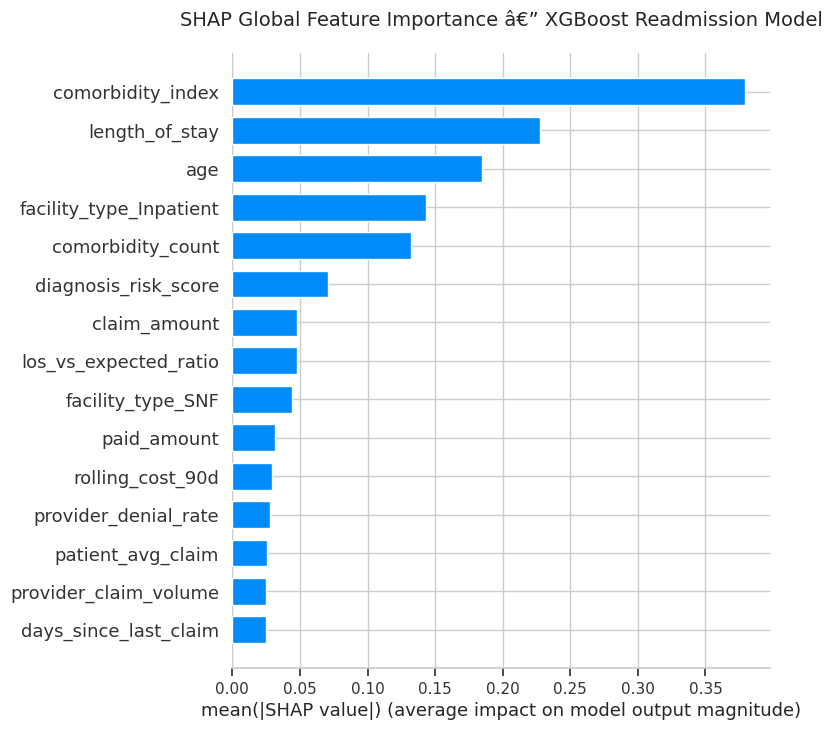

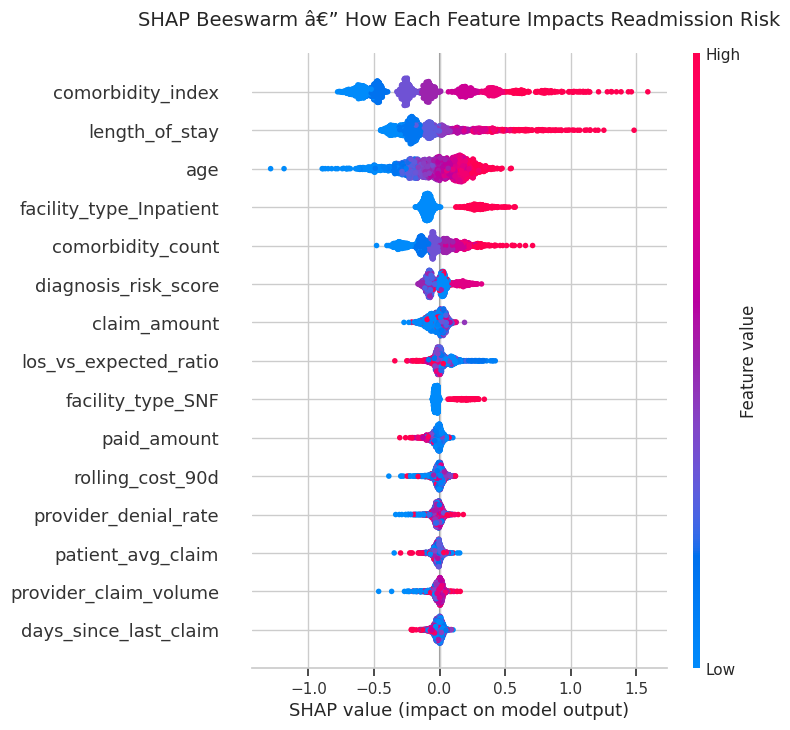

In [13]:
# ============================================================
# SHAP Summary Plot , Global Feature Importance
# ============================================================
import shap

# Sample for SHAP computation (full test set is slow for SHAP)
sample_size = min(2000, X_test.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_test.shape[0], sample_size, replace=False)
X_sample = X_test[sample_idx]

# Use TreeExplainer , fast & exact for tree models
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot (bar) , mean absolute SHAP value per feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names_xgb,
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP Global Feature Importance , XGBoost Readmission Model', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Summary plot (beeswarm) , per-feature impact distribution
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names_xgb,
                  max_display=15, show=False)
plt.title('SHAP Beeswarm , How Each Feature Impacts Readmission Risk', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Selected patient (sample index 160)
  Predicted readmission probability: 0.952
  Actual outcome: Readmitted


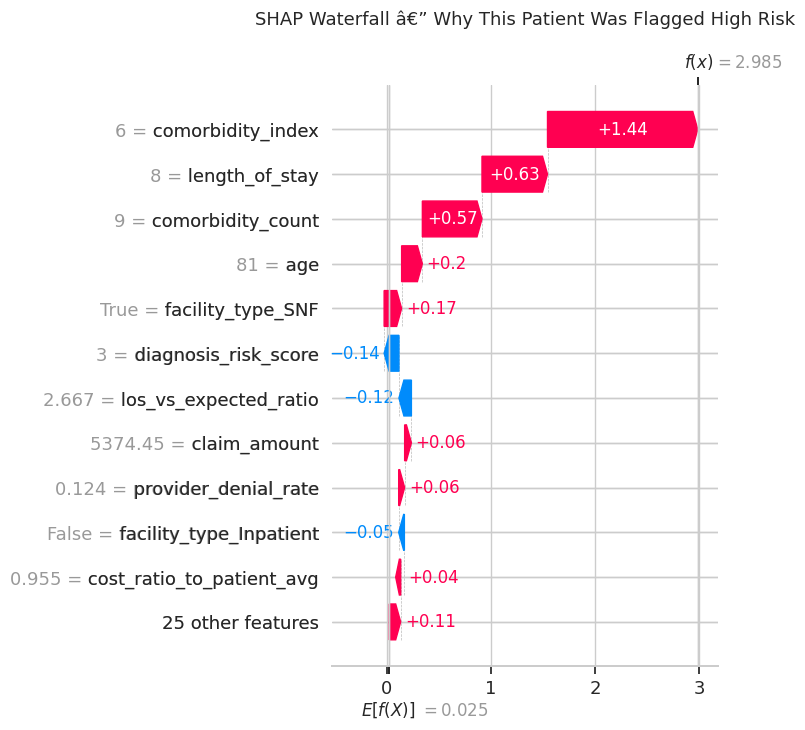

In [14]:
# ============================================================
# SHAP Waterfall , Local Explanation for a High-Risk Patient
# ============================================================
# Pick the patient with the highest predicted readmission probability
high_risk_idx = int(np.argmax(y_pred_proba[sample_idx]))
patient_shap = shap_values[high_risk_idx]
patient_features = X_sample[high_risk_idx]

print(f'Selected patient (sample index {high_risk_idx})')
print(f'  Predicted readmission probability: {y_pred_proba[sample_idx][high_risk_idx]:.3f}')
print(f'  Actual outcome: {"Readmitted" if y_test[sample_idx][high_risk_idx] == 1 else "Not readmitted"}')

plt.figure(figsize=(10, 8))
shap_exp = shap.Explanation(
    values=patient_shap,
    base_values=explainer.expected_value,
    data=patient_features,
    feature_names=feature_names_xgb,
)
shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.title('SHAP Waterfall , Why This Patient Was Flagged High Risk', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

---
## Step 7 , Precision-Recall Curve + Threshold Analysis

In clinical deployment, the **operating threshold** matters more than AUC-ROC. A hospital
care-management team has limited capacity to intervene, so they pick a threshold that
targets a specific precision (to avoid wasting resources) or recall (to catch high-risk patients).

This section shows:
- **PR curve**: precision vs recall across all thresholds (better than ROC for imbalanced data)
- **Threshold table**: precision, recall, and flag rate at several operating points
- **Recommended threshold**: the point that maximizes F1 score

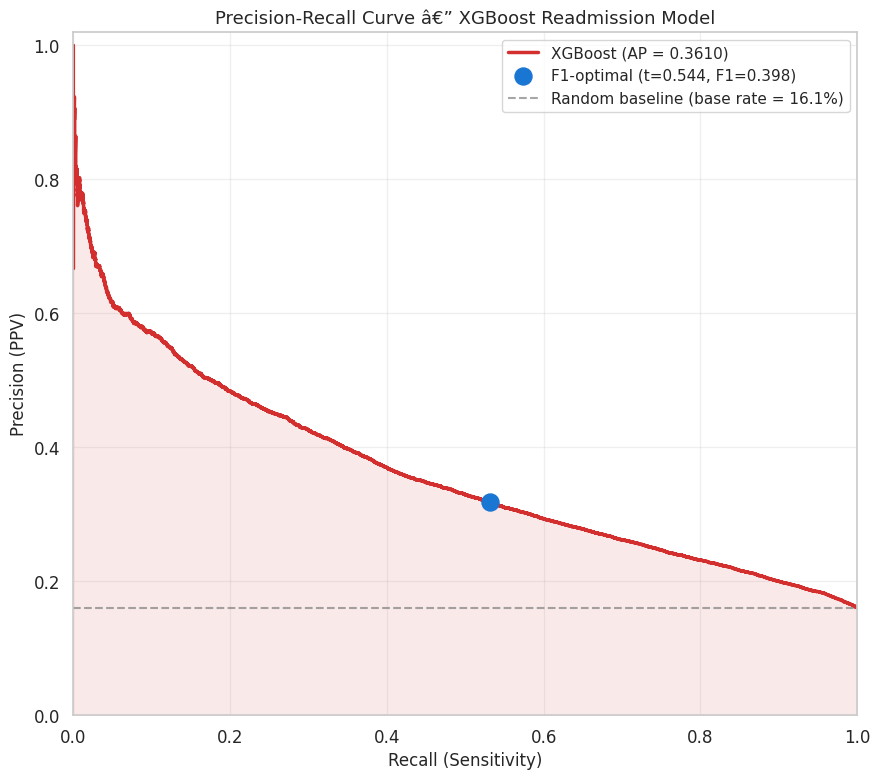


F1-optimal threshold: 0.5443
At this threshold: Precision=0.318, Recall=0.531


In [15]:
# ============================================================
# Precision-Recall Curve (XGBoost)
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)

# Find F1-optimal threshold
f1_scores = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-10)
best_f1_idx = int(np.argmax(f1_scores[:-1]))  # Last element has no threshold
best_threshold = thresholds_xgb[best_f1_idx]
best_f1_at_threshold = f1_scores[best_f1_idx]

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(recall_xgb, precision_xgb, color='#d32f2f', lw=2.5,
        label=f'XGBoost (AP = {avg_prec:.4f})')
ax.fill_between(recall_xgb, precision_xgb, alpha=0.1, color='#d32f2f')

# Mark the F1-optimal point
ax.scatter(recall_xgb[best_f1_idx], precision_xgb[best_f1_idx],
           color='#1976D2', s=150, zorder=5,
           label=f'F1-optimal (t={best_threshold:.3f}, F1={best_f1_at_threshold:.3f})')

# Horizontal line at positive class base rate
base_rate = y_test.mean()
ax.axhline(y=base_rate, color='gray', linestyle='--', alpha=0.7,
           label=f'Random baseline (base rate = {base_rate:.1%})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title('Precision-Recall Curve , XGBoost Readmission Model', fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nF1-optimal threshold: {best_threshold:.4f}')
print(f'At this threshold: Precision={precision_xgb[best_f1_idx]:.3f}, Recall={recall_xgb[best_f1_idx]:.3f}')

  THRESHOLD ANALYSIS â€” Operating Point Selection
 threshold  precision  recall  flag_rate  patients_flagged
      0.15      0.165   0.992      0.963             96306
      0.20      0.174   0.974      0.898             89791
      0.25      0.188   0.938      0.804             80357
      0.30      0.203   0.890      0.704             70411
      0.35      0.222   0.835      0.604             60434
      0.40      0.241   0.766      0.510             51010
      0.50      0.291   0.608      0.336             33583
      0.60      0.353   0.435      0.198             19772
      0.70      0.446   0.269      0.097              9688


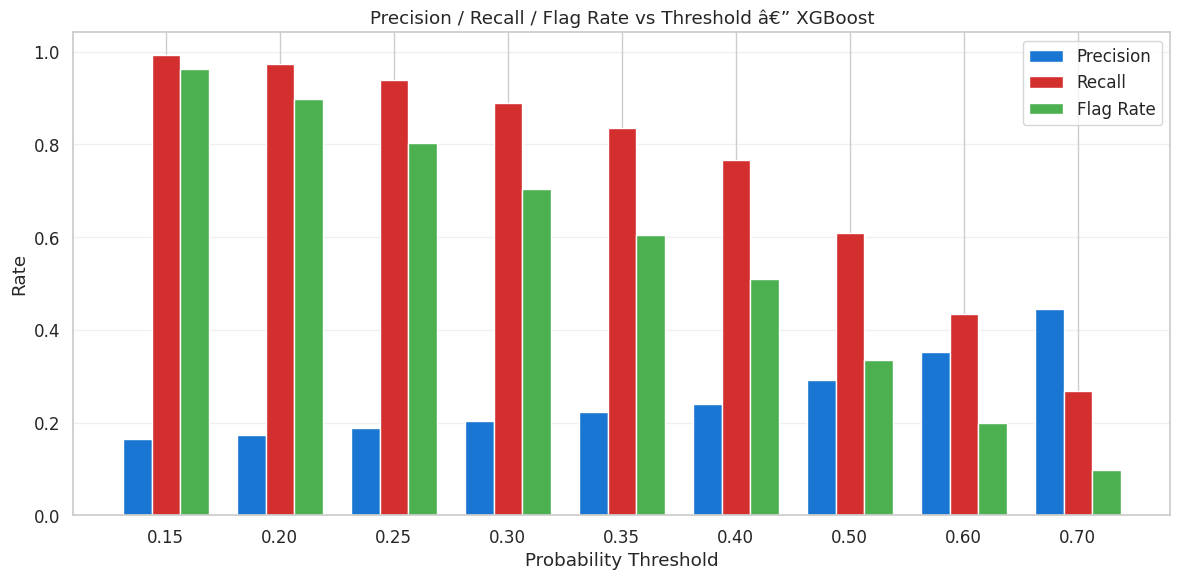


Recommendation: deploy at threshold 0.544 for F1-optimal performance.
Alternative (high-recall): lower threshold to catch more readmissions at cost of more false positives.


In [16]:
# ============================================================
# Threshold Analysis Table , pick an operating point
# ============================================================
# Show precision, recall, and "% of patients flagged" at several thresholds.
# This is the conversation you have with a care-management team:
# "At threshold 0.30, we flag 25% of patients with 42% precision and 80% recall."

threshold_values = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70]
rows = []
for t in threshold_values:
    y_hat = (y_pred_proba >= t).astype(int)
    if y_hat.sum() == 0:
        prec = 0.0
    else:
        prec = ((y_hat == 1) & (y_test == 1)).sum() / y_hat.sum()
    rec = ((y_hat == 1) & (y_test == 1)).sum() / max(y_test.sum(), 1)
    flag_rate = y_hat.mean()
    rows.append({
        'threshold': t,
        'precision': round(prec, 3),
        'recall': round(rec, 3),
        'flag_rate': round(flag_rate, 3),
        'patients_flagged': int(y_hat.sum()),
    })

threshold_df = pd.DataFrame(rows)
print('=' * 75)
print('  THRESHOLD ANALYSIS , Operating Point Selection')
print('=' * 75)
print(threshold_df.to_string(index=False))
print('=' * 75)

# Visualize as grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(threshold_df))
width = 0.25
ax.bar(x - width, threshold_df['precision'], width, label='Precision', color='#1976D2')
ax.bar(x,         threshold_df['recall'],    width, label='Recall',    color='#d32f2f')
ax.bar(x + width, threshold_df['flag_rate'], width, label='Flag Rate', color='#4caf50')
ax.set_xticks(x)
ax.set_xticklabels([f'{t:.2f}' for t in threshold_df['threshold']])
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Rate')
ax.set_title('Precision / Recall / Flag Rate vs Threshold , XGBoost')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nRecommendation: deploy at threshold {best_threshold:.3f} for F1-optimal performance.')
print(f'Alternative (high-recall): lower threshold to catch more readmissions at cost of more false positives.')

---
## Step 8 , Additional Visualizations

Domain-specific charts that give the reader a feel for the data: ROC curve (MLlib RF),
confusion matrix, MLlib feature importances, and EDA on denials, readmissions, costs,
age vs LOS, and the correlation matrix.

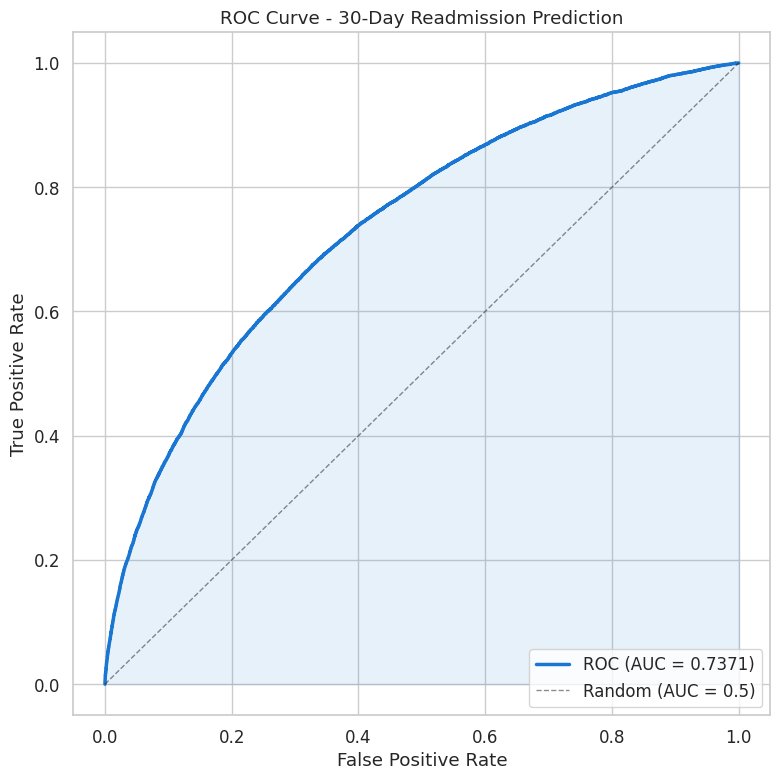

In [17]:
# ============================================================
# 1. ROC CURVE
# ============================================================
from pyspark.ml import PipelineModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix

# Reload model and generate predictions for plotting
model = PipelineModel.load(os.path.join(data_dir, 'models', 'readmission_model'))

# Reload claims for prediction (need the feature-engineered version)
# Re-run feature engineering on a fresh load to avoid stale cache
claims_fresh = spark.read.option('header','true').option('dateFormat','yyyy-MM-dd').schema(CLAIMS_SCHEMA).csv(os.path.join(data_dir, 'raw', 'claims.csv'))

from src.pipeline.transforms import add_rolling_claim_cost, add_lag_lead_features
from src.pipeline.feature_engineering import (
    add_diagnosis_risk_score, add_los_ratio, add_provider_denial_rate,
    add_payer_approval_rate, add_age_bucket, add_cost_features, add_comorbidity_index
)

plot_df = claims_fresh
plot_df = add_rolling_claim_cost(plot_df)
plot_df = add_lag_lead_features(plot_df)
plot_df = add_diagnosis_risk_score(plot_df)
plot_df = add_los_ratio(plot_df)
plot_df = add_provider_denial_rate(plot_df)
plot_df = add_payer_approval_rate(plot_df)
plot_df = add_age_bucket(plot_df)
plot_df = add_cost_features(plot_df)
plot_df = add_comorbidity_index(plot_df)
plot_df = plot_df.fillna({
    'days_since_last_claim': -1, 'prev_denial_flag': 0, 'prev_claim_amount': 0.0,
    'rolling_cost_90d': 0.0, 'claim_count_90d': 0, 'claim_sequence': 1,
    'provider_denial_rate': 0.0, 'provider_claim_volume': 0,
    'payer_approval_rate': 0.85, 'patient_avg_claim': 0.0,
    'patient_total_claims': 1, 'cost_ratio_to_patient_avg': 1.0,
})
plot_df = plot_df.withColumn('readmission_30day', F.col('readmission_30day').cast('integer'))

# Use only test split
_, test_df = plot_df.randomSplit([0.8, 0.2], seed=42)
predictions = model.transform(test_df)

roc_data = (
    predictions
    .select('readmission_30day', vector_to_array('probability').alias('p'))
    .withColumn('prob_pos', F.col('p')[1])
    .select('readmission_30day', 'prob_pos')
    .toPandas()
)
fpr, tpr, _ = roc_curve(roc_data['readmission_30day'], roc_data['prob_pos'])
roc_auc = sk_auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#1976D2', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#1976D2')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - 30-Day Readmission Prediction')
ax.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

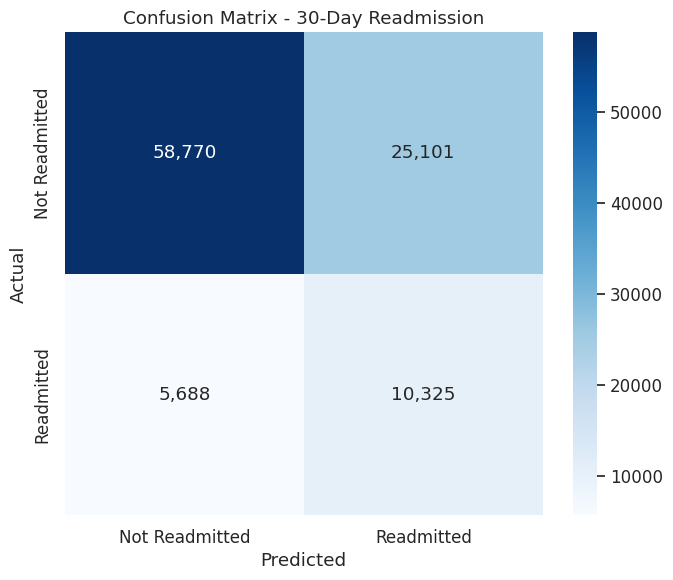

In [18]:
# ============================================================
# 2. CONFUSION MATRIX
# ============================================================

pred_pd = predictions.select('readmission_30day', 'prediction').toPandas()
cm = confusion_matrix(pred_pd['readmission_30day'], pred_pd['prediction'])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Not Readmitted','Readmitted'],
            yticklabels=['Not Readmitted','Readmitted'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - 30-Day Readmission')
plt.tight_layout()
plt.show()

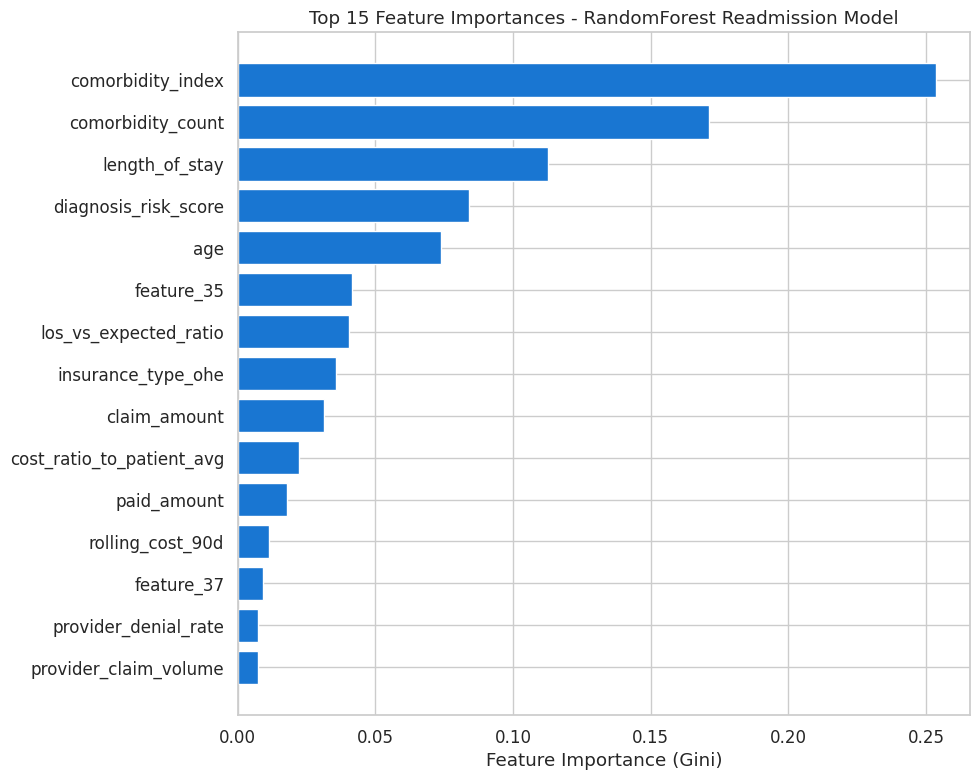

In [19]:
# ============================================================
# 3. FEATURE IMPORTANCE BAR CHART
# ============================================================

fi_df = pd.DataFrame(feat_imp[:15]).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi_df['feature'], fi_df['importance'], color='#1976D2')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 15 Feature Importances - RandomForest Readmission Model')
plt.tight_layout()
plt.show()

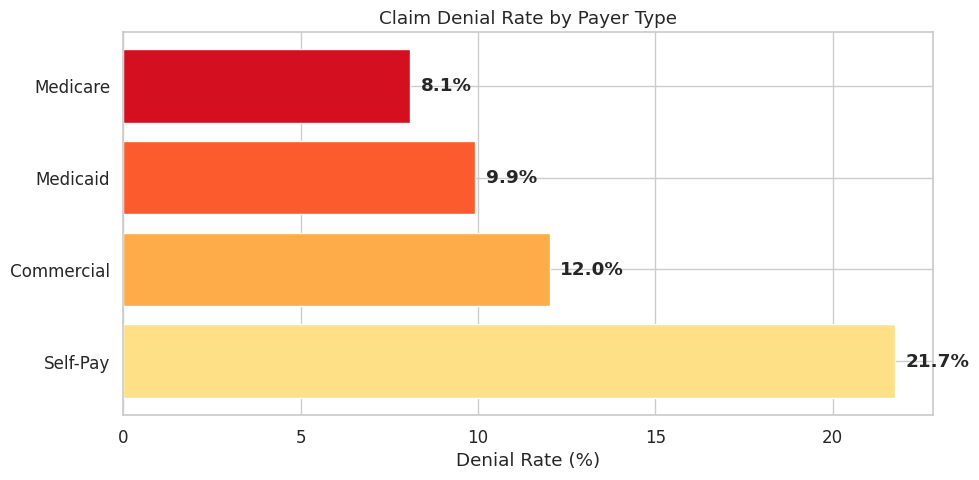

In [20]:
# ============================================================
# 4. DENIAL RATE BY PAYER
# ============================================================

denial_pd = (
    claims_fresh.groupBy('payer_type')
    .agg(F.avg('denial_flag').alias('denial_rate'), F.count('*').alias('n'))
    .orderBy(F.col('denial_rate').desc())
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(denial_pd['payer_type'], denial_pd['denial_rate'] * 100,
               color=sns.color_palette('YlOrRd', len(denial_pd)))
ax.set_xlabel('Denial Rate (%)')
ax.set_title('Claim Denial Rate by Payer Type')
for bar, rate in zip(bars, denial_pd['denial_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{rate:.1%}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

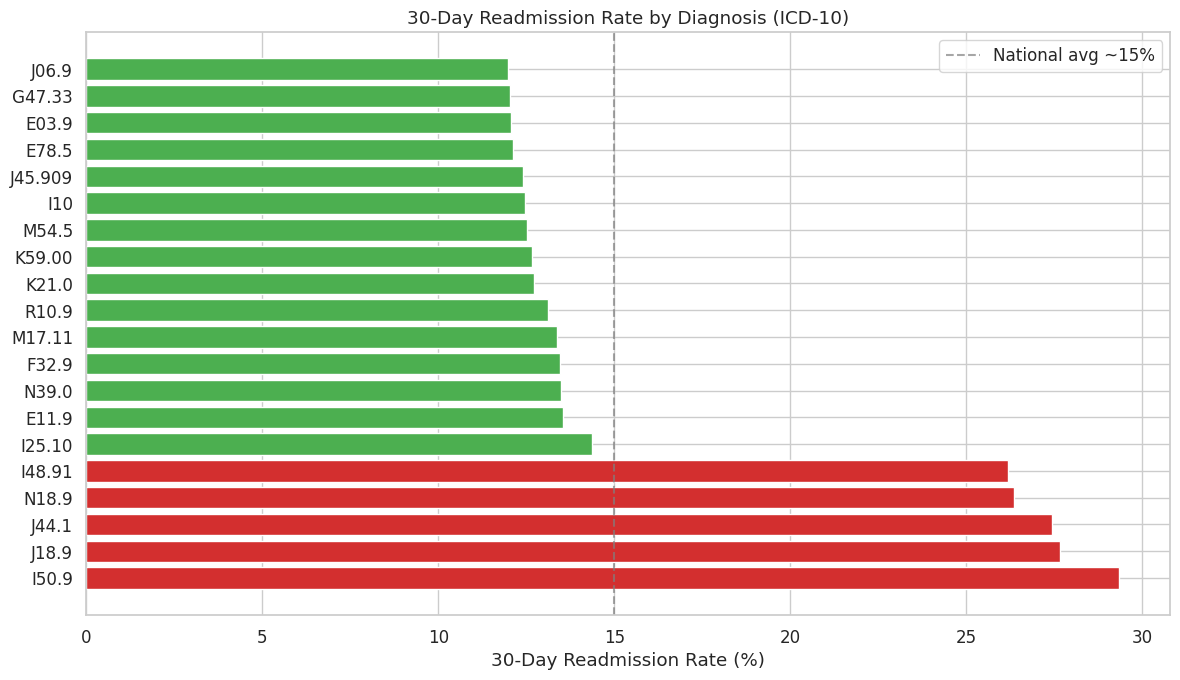

In [21]:
# ============================================================
# 5. READMISSION RATE BY DIAGNOSIS
# ============================================================

readmit_pd = (
    claims_fresh.groupBy('diagnosis_code')
    .agg(F.avg('readmission_30day').alias('readmit_rate'), F.count('*').alias('n'))
    .where(F.col('n') >= 1000)
    .orderBy(F.col('readmit_rate').desc())
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#d32f2f' if r > 0.20 else '#f57c00' if r > 0.15 else '#4caf50'
          for r in readmit_pd['readmit_rate']]
ax.barh(readmit_pd['diagnosis_code'], readmit_pd['readmit_rate'] * 100, color=colors)
ax.set_xlabel('30-Day Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Diagnosis (ICD-10)')
ax.axvline(x=15, color='gray', linestyle='--', alpha=0.7, label='National avg ~15%')
ax.legend()
plt.tight_layout()
plt.show()

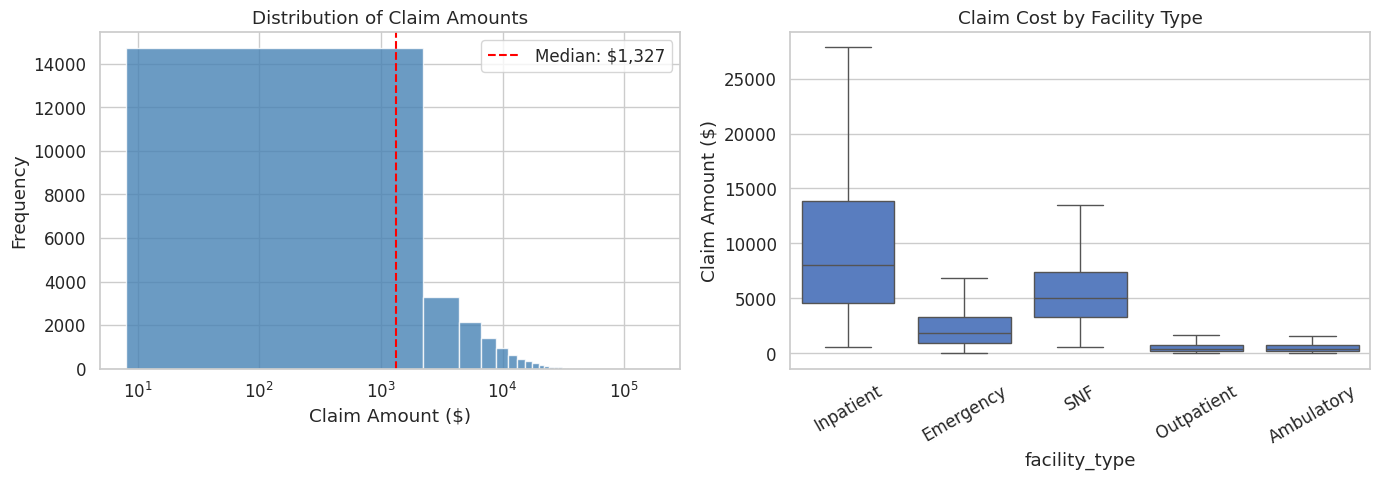

In [22]:
# ============================================================
# 6. COST DISTRIBUTION BY FACILITY TYPE
# ============================================================

cost_sample = claims_fresh.select('claim_amount','facility_type').sample(0.05, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cost_sample['claim_amount'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Claim Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Claim Amounts')
axes[0].set_xscale('log')
axes[0].axvline(cost_sample['claim_amount'].median(), color='red', linestyle='--',
                label=f'Median: ${cost_sample["claim_amount"].median():,.0f}')
axes[0].legend()

sns.boxplot(data=cost_sample, x='facility_type', y='claim_amount', ax=axes[1], showfliers=False)
axes[1].set_ylabel('Claim Amount ($)')
axes[1].set_title('Claim Cost by Facility Type')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

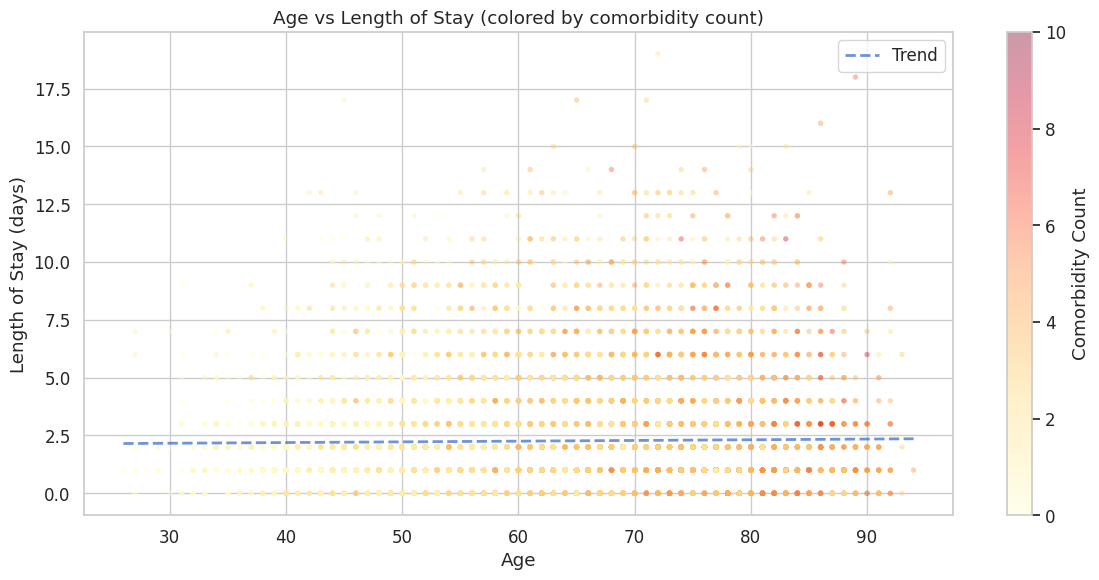

In [23]:
# ============================================================
# 7. AGE vs LENGTH OF STAY
# ============================================================

age_los = claims_fresh.select('age','length_of_stay','comorbidity_count').sample(0.02, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(age_los['age'], age_los['length_of_stay'],
                     c=age_los['comorbidity_count'], cmap='YlOrRd',
                     alpha=0.4, s=15, edgecolors='none')
plt.colorbar(scatter, label='Comorbidity Count')
ax.set_xlabel('Age')
ax.set_ylabel('Length of Stay (days)')
ax.set_title('Age vs Length of Stay (colored by comorbidity count)')
z = np.polyfit(age_los['age'], age_los['length_of_stay'], 1)
p = np.poly1d(z)
ax.plot(sorted(age_los['age'].unique()), p(sorted(age_los['age'].unique())),
        'b--', alpha=0.8, linewidth=2, label='Trend')
ax.legend()
plt.tight_layout()
plt.show()

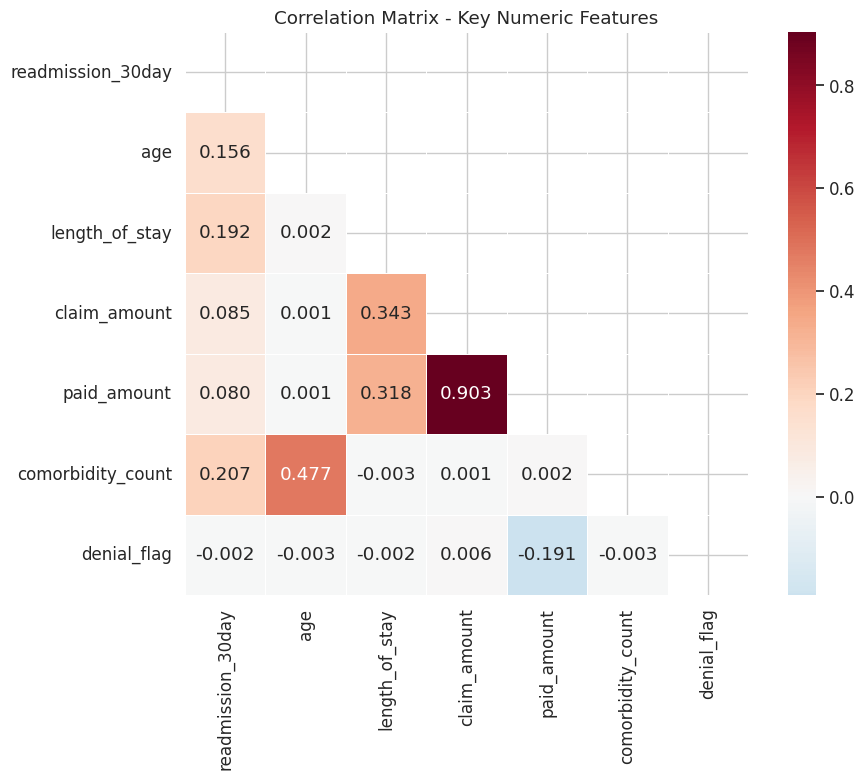

In [24]:
# ============================================================
# 8. CORRELATION MATRIX
# ============================================================

corr_cols = ['readmission_30day','age','length_of_stay','claim_amount','paid_amount',
             'comorbidity_count','denial_flag']
corr_data = claims_fresh.select(corr_cols).sample(0.1, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix - Key Numeric Features')
plt.tight_layout()
plt.show()

---
## Final Summary

In [25]:
print('=' * 75)
print('  HEALTHSPARK-CLAIMS-ANALYTICS - FULL PIPELINE RESULTS')
print('=' * 75)
print(f'\n  Dataset:')
print(f'    Claims:        500,000')
print(f'    Patients:      50,000')
print(f'    Features:      {len(feature_names_xgb)} (20 numeric + one-hot categoricals)')

print(f'\n  3-Model Comparison (AUC-ROC / AUC-PR):')
for name, m in all_models.items():
    print(f"    {name:<22} AUC-ROC={m['auc_roc']:.4f}  AUC-PR={m['auc_pr']:.4f}  F1={m['f1_score']:.4f}")

best_name, best_m = max(all_models.items(), key=lambda kv: kv[1]['auc_pr'])
print(f'\n  Best model: {best_name} (by AUC-PR = {best_m["auc_pr"]:.4f})')

print(f'\n  XGBoost GPU training: {xgb_elapsed:.1f}s on {device_used}')
print(f'  F1-optimal threshold: {best_threshold:.4f}')
print(f'    -> Precision {precision_xgb[best_f1_idx]:.3f}, Recall {recall_xgb[best_f1_idx]:.3f}')

print(f'\n  Top 5 Features (MLlib Random Forest):')
for i, f in enumerate(feat_imp[:5]):
    print(f'    {i+1}. {f["feature"]:<30} {f["importance"]:.4f}')

print('=' * 75)
print('\n  HealthSpark-Claims-Analytics: Distributed Healthcare Claims Analytics & ML Pipeline')
print(f'  Repository: https://github.com/Deepak-Lingala/HealthSpark-Claims-Analytics')

  HEALTHSPARK-CLAIMS-ANALYTICS - FULL PIPELINE RESULTS

  Dataset:
    Claims:        500,000
    Patients:      50,000
    Features:      36 (20 numeric + one-hot categoricals)

  3-Model Comparison (AUC-ROC / AUC-PR):
    Logistic Regression    AUC-ROC=0.7261  AUC-PR=0.3658  F1=0.7201
    Random Forest          AUC-ROC=0.7258  AUC-PR=0.3625  F1=0.7248
    XGBoost (GPU)          AUC-ROC=0.7237  AUC-PR=0.3610  F1=0.7345

  Best model: Logistic Regression (by AUC-PR = 0.3658)

  XGBoost GPU training: 3.9s on GPU (CUDA)
  F1-optimal threshold: 0.5443
    -> Precision 0.318, Recall 0.531

  Top 5 Features (MLlib Random Forest):
    1. comorbidity_index              0.2534
    2. comorbidity_count              0.1711
    3. length_of_stay                 0.1129
    4. diagnosis_risk_score           0.0841
    5. age                            0.0738

  HealthSpark-Claims-Analytics: Distributed Healthcare Claims Analytics & ML Pipeline
  Repository: https://github.com/Deepak-Lingala/HealthS

In [26]:
spark.stop()
print('SparkSession stopped. Pipeline complete.')

SparkSession stopped. Pipeline complete.


In [ ]:
!cd /content/HealthSpark-Claims-Analytics && git config user.email ""
!cd /content/HealthSpark-Claims-Analytics && git config user.name "Deepak-Lingala"